In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Dataset Loading and Inspection

In [3]:
df = pd.read_csv("Unemployment in India.csv")
print("Dataset Loaded Successfully !")

Dataset Loaded Successfully !


In [4]:
df.head(10)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
5,Andhra Pradesh,31-10-2019,Monthly,3.52,12017412.0,43.01,Rural
6,Andhra Pradesh,30-11-2019,Monthly,4.12,11397681.0,41.00,Rural
7,Andhra Pradesh,31-12-2019,Monthly,4.38,12528395.0,45.14,Rural
8,Andhra Pradesh,31-01-2020,Monthly,4.84,12016676.0,43.46,Rural
9,Andhra Pradesh,29-02-2020,Monthly,5.91,11723617.0,42.83,Rural


In [5]:
print(f"Dataset Dimention row × column : {df.shape[0]} × {df.shape[1]}")

Dataset Dimention row × column : 768 × 7


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    740 non-null    object 
 1    Date                                     740 non-null    object 
 2    Frequency                                740 non-null    object 
 3    Estimated Unemployment Rate (%)          740 non-null    float64
 4    Estimated Employed                       740 non-null    float64
 5    Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 42.1+ KB


In [7]:
df.columns = df.columns.str.strip()

In [8]:
df.columns

Index(['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)',
       'Estimated Employed', 'Estimated Labour Participation Rate (%)',
       'Area'],
      dtype='object')

In [9]:
df.describe()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
count,740.000000,7.400000e+02,740.000000
mean,11.787946,7.204460e+06,42.630122
std,10.721298,8.087988e+06,8.111094
min,0.000000,4.942000e+04,13.330000
25%,4.657500,1.190404e+06,38.062500
50%,8.350000,4.744178e+06,41.160000
75%,15.887500,1.127549e+07,45.505000
max,76.740000,4.577751e+07,72.570000


## Data Cleaning and Handling

In [10]:
df.isnull().sum()

Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64

In [11]:
df.isnull().mean().round(4)

Region                                     0.0365
Date                                       0.0365
Frequency                                  0.0365
Estimated Unemployment Rate (%)            0.0365
Estimated Employed                         0.0365
Estimated Labour Participation Rate (%)    0.0365
Area                                       0.0365
dtype: float64

In [12]:
df = df.dropna()
print("Deleted Rows with Null Values")

Deleted Rows with Null Values


In [13]:
df.shape

(740, 7)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
df = df.drop_duplicates()
print("Droped Duplicate Rows")

Droped Duplicate Rows


In [16]:
df['Frequency'] = df['Frequency'].str.strip()

## Statistical Outlier Identification with IQR method

In [17]:
numeric_cols = df[['Estimated Unemployment Rate (%)','Estimated Employed', 'Estimated Labour Participation Rate (%)',]]

In [18]:
numeric_cols.head()

,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%)
0,3.65,11999139.0,43.24
1,3.05,11755881.0,42.05
2,3.75,12086707.0,43.50
3,3.32,12285693.0,43.97
4,5.17,12256762.0,44.68


In [19]:
Q1 = numeric_cols['Estimated Employed'].quantile(0.25)
Q3 = numeric_cols['Estimated Employed'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q1 + 1.5*IQR

df[numeric_cols['Estimated Employed'] > upper].count()


Region                                     72
Date                                       72
Frequency                                  72
Estimated Unemployment Rate (%)            72
Estimated Employed                         72
Estimated Labour Participation Rate (%)    72
Area                                       72
dtype: int64

In [20]:
Q1 = numeric_cols['Estimated Unemployment Rate (%)'].quantile(0.25)
Q3 = numeric_cols['Estimated Unemployment Rate (%)'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q1 + 1.5*IQR

df[numeric_cols['Estimated Unemployment Rate (%)'] > upper].count()

Region                                     108
Date                                       108
Frequency                                  108
Estimated Unemployment Rate (%)            108
Estimated Employed                         108
Estimated Labour Participation Rate (%)    108
Area                                       108
dtype: int64

In [21]:
Q1 = numeric_cols['Estimated Labour Participation Rate (%)'].quantile(0.25)
Q3 = numeric_cols['Estimated Labour Participation Rate (%)'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q1 + 1.5*IQR

df[numeric_cols['Estimated Labour Participation Rate (%)'] > upper].count()


Region                                     102
Date                                       102
Frequency                                  102
Estimated Unemployment Rate (%)            102
Estimated Employed                         102
Estimated Labour Participation Rate (%)    102
Area                                       102
dtype: int64

In [22]:
df.groupby('Area')['Estimated Unemployment Rate (%)'].mean()

Area
Rural    10.324791
Urban    13.166614
Name: Estimated Unemployment Rate (%), dtype: float64

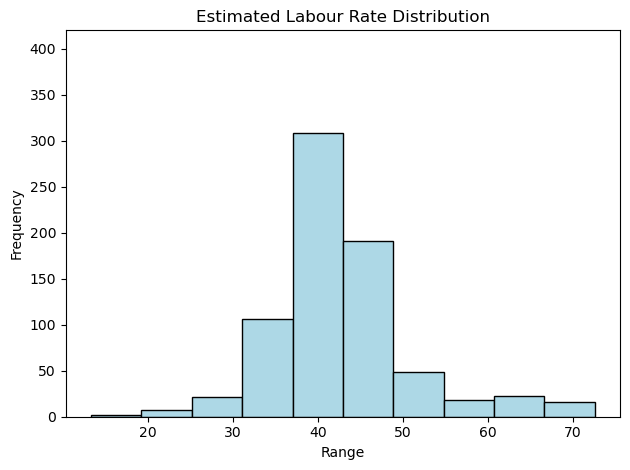

In [23]:
plt.hist(df['Estimated Labour Participation Rate (%)'], bins=10, color='lightblue', edgecolor='black')
plt.title('Estimated Labour Rate Distribution')
plt.xlabel('Range')
plt.ylabel('Frequency')
plt.ylim(0,420)
plt.tight_layout()
plt.show()

In [24]:
print("Top 5 Regions with high unemployment rate")
df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False).nlargest(5)

Top 5 Regions with high unemployment rate


Region
Tripura             28.350357
Haryana             26.283214
Jharkhand           20.585000
Bihar               18.918214
Himachal Pradesh    18.540357
Name: Estimated Unemployment Rate (%), dtype: float64

In [25]:
df.head()

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural


In [26]:
df['Area'].value_counts()

Area
Urban    381
Rural    359
Name: count, dtype: int64

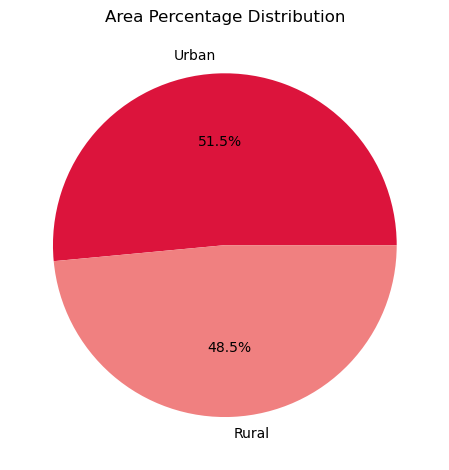

In [27]:
plt.pie(df['Area'].value_counts().values.tolist(), labels=df['Area'].value_counts().index,autopct='%0.01f%%',colors=['crimson','lightcoral'])
plt.title("Area Percentage Distribution", fontsize=12)
plt.tight_layout()
plt.show()

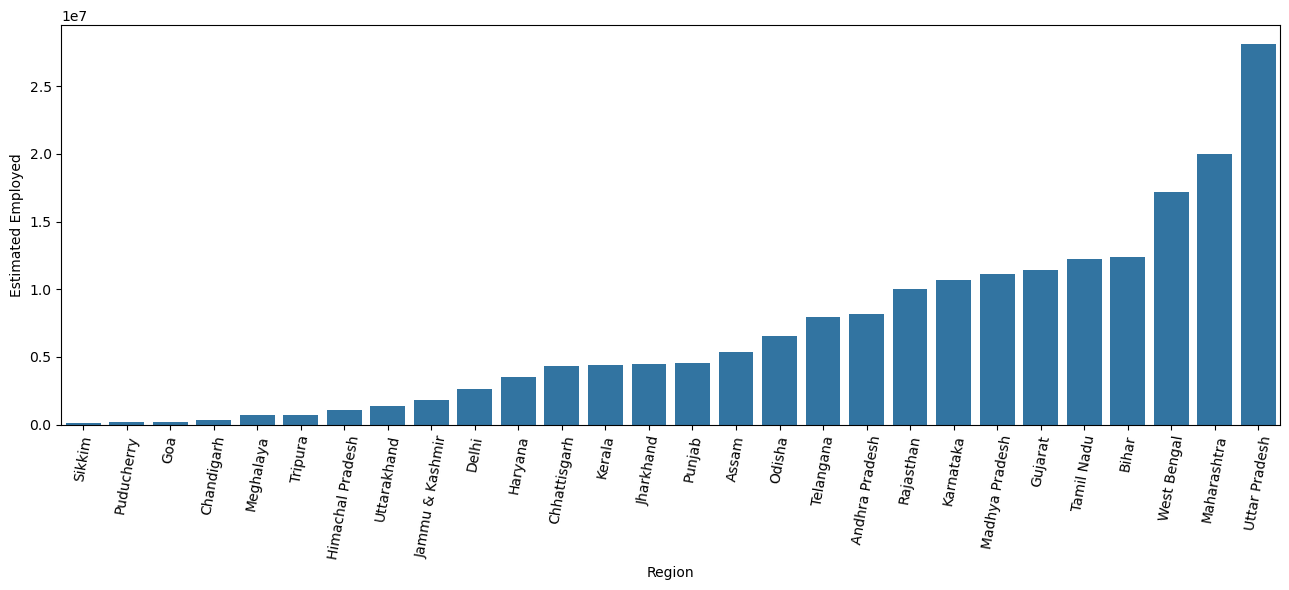

In [28]:
plt.figure(figsize=(13,6))
sns.barplot(x=df.groupby('Region')['Estimated Employed'].mean().sort_values().index, 
            y=df.groupby('Region')['Estimated Employed'].mean().sort_values().values)
# plt.ylim(0,max(df['Estimated Employed']))
plt.ylabel('Estimated Employed')
plt.xticks(rotation=80)
plt.tight_layout()
plt.show()

In [29]:
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

before_covid = df[df["Date"] < "2020-03-01"]
during_covid = df[df["Date"] >= "2020-03-01"]

print("Average Unemployment Rate Before COVID-19:",
      round(before_covid["Estimated Unemployment Rate (%)"].mean(),2))

print("Average Unemployment Rate During COVID-19:",
      round(during_covid["Estimated Unemployment Rate (%)"].mean(),2))

Average Unemployment Rate Before COVID-19: 9.51
Average Unemployment Rate During COVID-19: 17.77


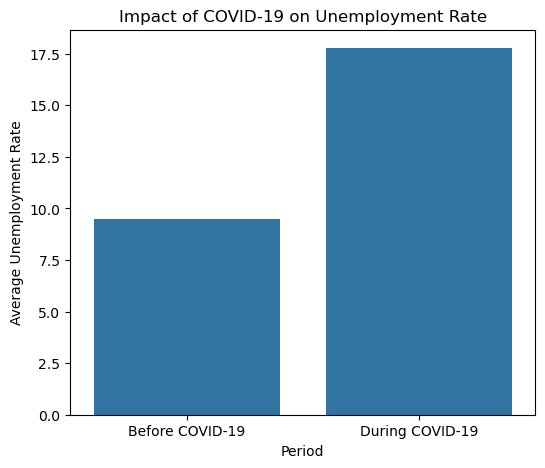

In [30]:
comparison = pd.DataFrame({
    "Period": ["Before COVID-19", "During COVID-19"],
    "Average Unemployment Rate": [
        before_covid["Estimated Unemployment Rate (%)"].mean(),
        during_covid["Estimated Unemployment Rate (%)"].mean()
    ]
})

plt.figure(figsize=(6,5))

sns.barplot(
    data=comparison,
    x="Period",
    y="Average Unemployment Rate"
)

plt.title("Impact of COVID-19 on Unemployment Rate")
plt.show()

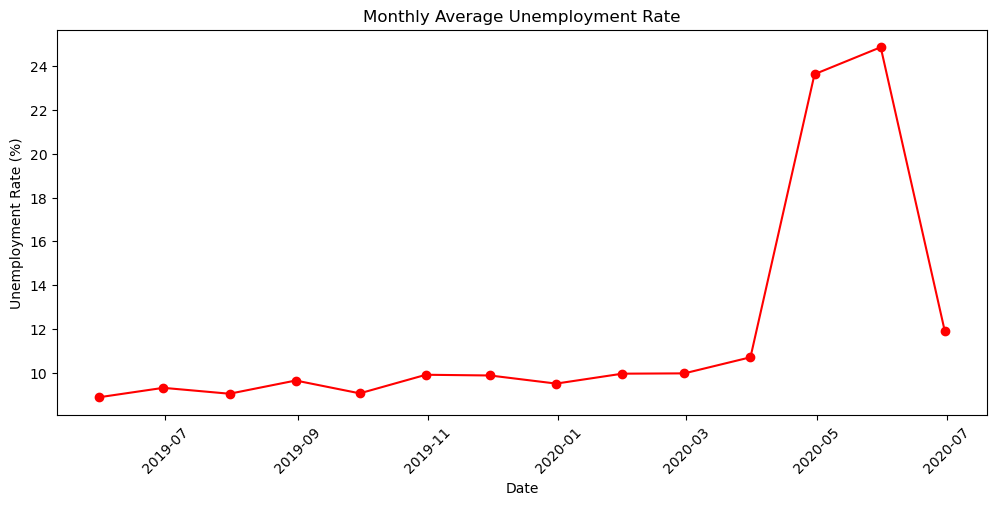

In [34]:
monthly_trend = df.groupby("Date")["Estimated Unemployment Rate (%)"].mean()

plt.figure(figsize=(12,5))

plt.plot(
    monthly_trend.index,
    monthly_trend.values,
    marker="o",
    color='red'
)

plt.title("Monthly Average Unemployment Rate")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

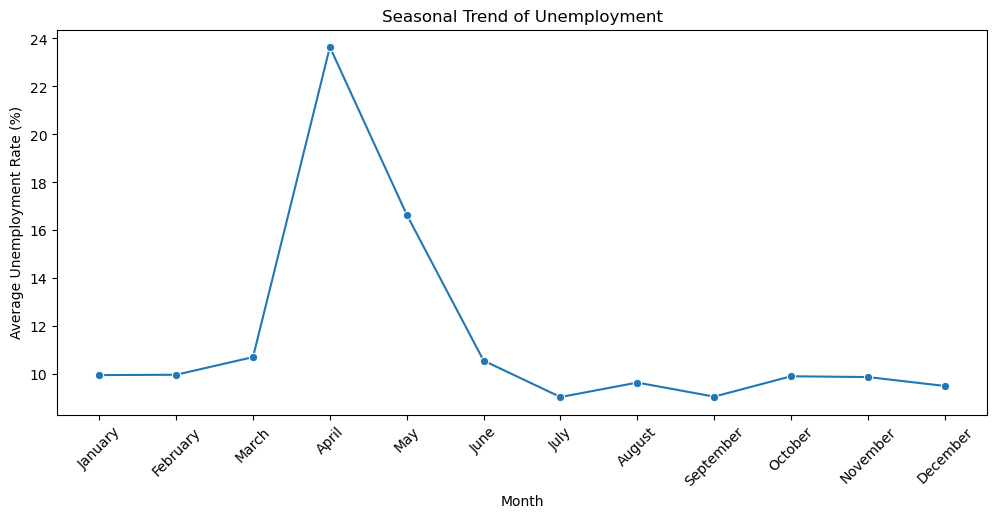

In [32]:
df["Month"] = df["Date"].dt.month_name()

month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

seasonal = df.groupby("Month")["Estimated Unemployment Rate (%)"].mean()

seasonal = seasonal.reindex(month_order)

plt.figure(figsize=(12,5))

sns.lineplot(
    x=seasonal.index,
    y=seasonal.values,
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Seasonal Trend of Unemployment")

plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.show()

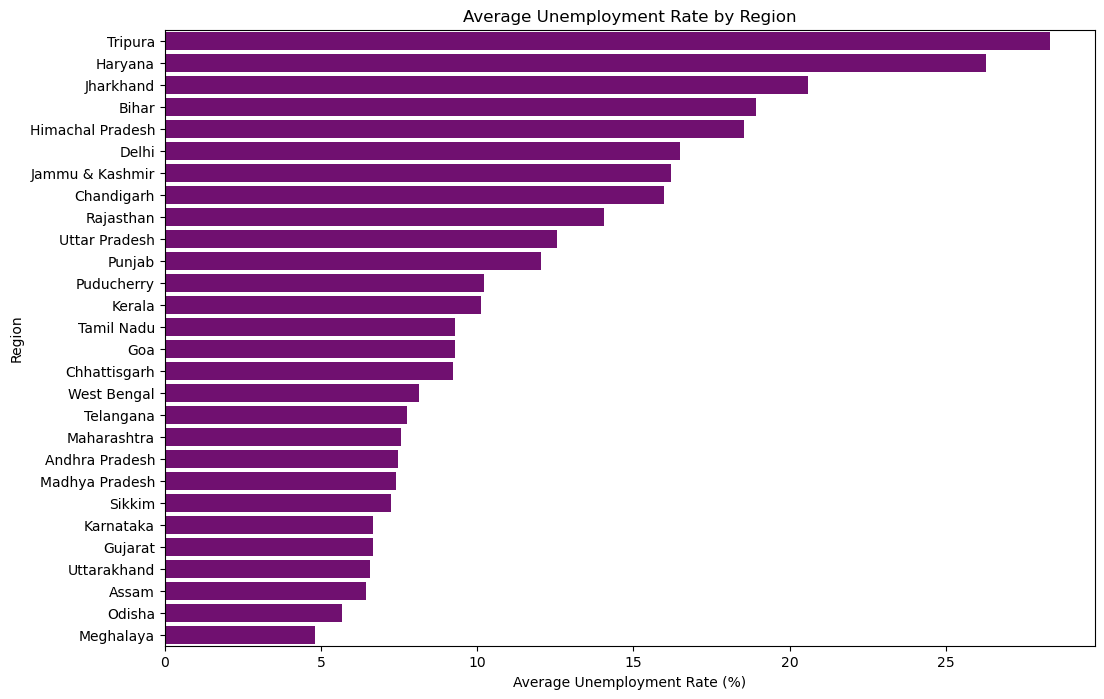

In [36]:
region = df.groupby("Region")["Estimated Unemployment Rate (%)"].mean().sort_values(ascending=False)

plt.figure(figsize=(12,8))

sns.barplot(
    x=region.values,
    y=region.index,
    color='purple'
)

plt.title("Average Unemployment Rate by Region")

plt.xlabel("Average Unemployment Rate (%)")

plt.show()

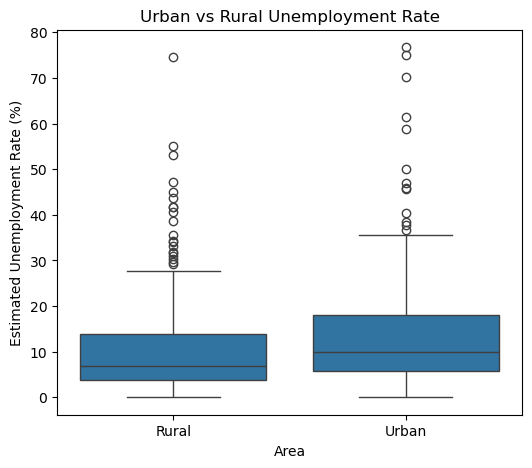

In [37]:
plt.figure(figsize=(6,5))

sns.boxplot(
    data=df,
    x="Area",
    y="Estimated Unemployment Rate (%)"
)

plt.title("Urban vs Rural Unemployment Rate")

plt.show()

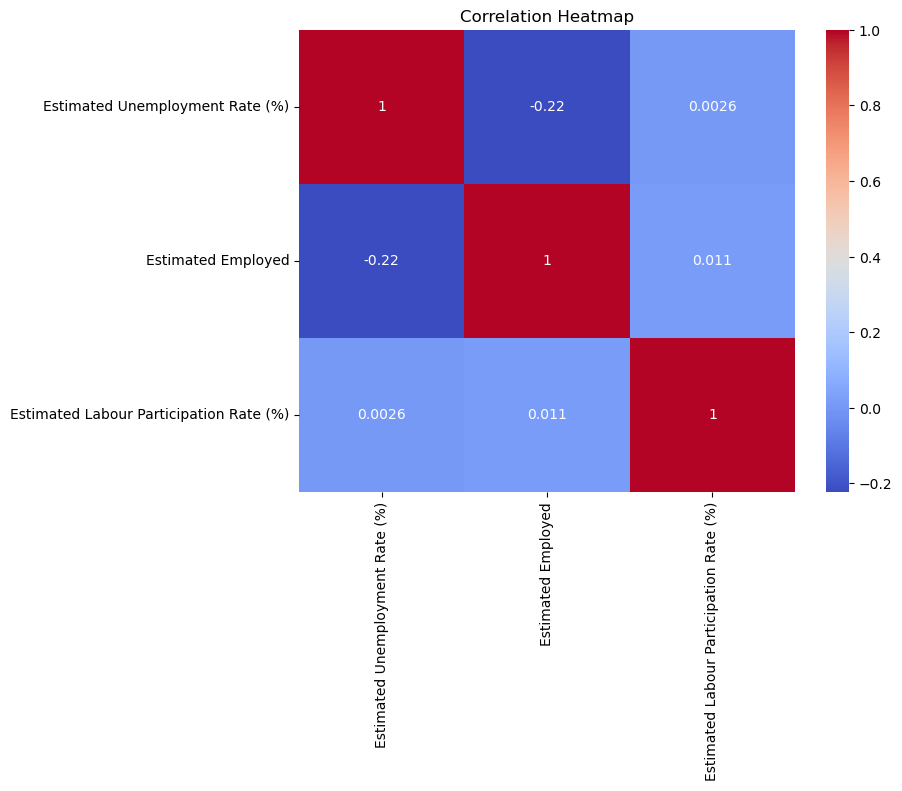

In [39]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()